В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/Kateryna-Korniichuk/ml_home_tasks.git
%cd ml_home_tasks
!ls

Cloning into 'ml_home_tasks'...
remote: Enumerating objects: 87, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 87 (delta 32), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (87/87), 4.76 MiB | 9.26 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/ml_home_tasks
 HW_1_1_Основи_статистики.ipynb
 HW_1_2_Credit_EDA.ipynb
 HW1_Змінні_та_основні_типи_даних_в_Python.ipynb
 HW_2_1_Лінійна_регресія_від_багатьох_змінних.ipynb
'HW_2_1_Матриці_і_вектори_(вступ_до_лін_алгебри).ipynb'
 HW_2_1_Побудова_лінійної_регресії_за_одною_ознакою.ipynb
 HW_2_1_Тестування_стат_гіпотез.ipynb
 HW_2_1_Функції_і_похідні.ipynb
 HW_2_2_Логістична_регресія_з_scikit_learn.ipynb
 HW_2_2_Математичне_формулювання_логістичної_регресії.ipynb
 HW_2_2_Незбалансована_багатокласова_класифікація.ipynb
 HW_2_2_Поліноміальні_ознаки_Pipelines.ipynb
 HW_2_3_Дерева_прийняття_рішень.ipynb
 HW2_Списки_та_словники.ipynb
'HW3_Умовні

In [3]:
from process_bank_churn import preprocess_data, preprocess_new_data

In [4]:
import pandas as pd
import numpy as np

raw_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train.csv')

X_train, train_targets, X_val, val_targets, input_cols, scaler, encoder = preprocess_data(raw_df, scale_numeric_flag=True)

print(X_train.shape, X_val.shape)

(12000, 11) (3000, 11)


1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)

KNeighborsClassifier()

In [6]:
from sklearn.metrics import roc_auc_score

print("area under ROC train:", roc_auc_score(train_targets, knn.predict_proba(X_train)[:,1]).round(3))
print("area under ROC validation:", roc_auc_score(val_targets, knn.predict_proba(X_val)[:,1]).round(3))


area under ROC train: 0.961
area under ROC validation: 0.883


**Висновки**

модель не погана, AUROC на train 0.961, на test 0.883. Є ознаки оверфіттінг - high variance, бо на train метрика набагато вища ніж на тест, модель не дуже добре генералізує

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [7]:
knn = KNeighborsClassifier()
params_knn = {'n_neighbors': np.arange(1, 25)}
knn_gs = GridSearchCV(knn, params_knn, cv=5)
knn_gs.fit(X_train, train_targets)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])})

In [8]:
knn_best = knn_gs.best_estimator_

print(knn_gs.best_params_, knn_gs.best_score_)

{'n_neighbors': np.int64(16)} 0.8907499999999999


In [9]:
print("area under ROC train:", roc_auc_score(train_targets, knn_best.predict_proba(X_train)[:,1]).round(3))
print("area under ROC validation:", roc_auc_score(val_targets, knn_best.predict_proba(X_val)[:,1]).round(3))


area under ROC train: 0.945
area under ROC validation: 0.919


**Висновки**

Оптимальне значення параметра n_neighbors = 16

Метрика найкращої моделі AUROC на train 0.945 на test 0.919. У порівнянні з моделлю з завдання 2, AUROC на валідаційній вибірці збільшилась, що свідчить про кращу узагальнюючу здатність моделі

Порівняно з моделлю Decision Tree з попереднього домашнього завдання AUROC = 0.922, kNN показує трохи нижчий результат, але різниця є незначною

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [10]:
%%time
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
params_dt = {'max_depth': np.arange(1, 21, 2), 'max_leaf_nodes': np.arange(2, 11)}
dt_gs = GridSearchCV(dt, params_dt, cv=3, scoring='roc_auc')

dt_gs.fit(X_train, train_targets)

CPU times: user 5.09 s, sys: 0 ns, total: 5.09 s
Wall time: 5.12 s


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                         'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10])},
             scoring='roc_auc')

In [11]:
dt_best = dt_gs.best_estimator_

print(dt_gs.best_params_, dt_gs.best_score_)

{'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(10)} 0.899058663182957


In [12]:
print("AUROC train:", roc_auc_score(train_targets, dt_best.predict_proba(X_train)[:,1]).round(3))
print("AUROC validation:", roc_auc_score(val_targets, dt_best.predict_proba(X_val)[:,1]).round(3))


AUROC train: 0.902
AUROC validation: 0.896


**Висновки**

Це гарна модель, але не ідеальна. Та, що я знайшла вручну мала AUROC на validation 0.924. Причина полягає в тому, що сітка параметрів у GridSearchCV була обмежена значеннями max_leaf_nodes від 2 до 10, оптимальніші значення не були включені в пошук

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [13]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [33]:
%%time
from sklearn.model_selection import RandomizedSearchCV

dt = DecisionTreeClassifier(random_state=42)

dt_random = RandomizedSearchCV(dt, params_dt, cv=3, n_iter=40, scoring='roc_auc', random_state=42)

dt_random.fit(X_train, train_targets)

CPU times: user 2.06 s, sys: 6.72 ms, total: 2.07 s
Wall time: 2.38 s


RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=40,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19]),
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'splitter': ['best', 'random']},
                   random_state=42, scoring='roc_auc')

In [34]:
dt_random_search_best = dt_random.best_estimator_

print(dt_random.best_params_, dt_random.best_score_)

{'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'} 0.9110154067781187


In [35]:
print("area under ROC train:", roc_auc_score(train_targets, dt_random_search_best.predict_proba(X_train)[:,1]).round(3))
print("area under ROC validation:", roc_auc_score(val_targets, dt_random_search_best.predict_proba(X_val)[:,1]).round(3))


area under ROC train: 0.916
area under ROC validation: 0.915


In [32]:
print(dt_gs.best_params_, dt_gs.best_score_)

{'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(10)} 0.899058663182957


In [25]:
print(dt_random.best_params_, dt_random.best_score_)

{'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'} 0.9110154067781187


**Висновки**

Модель вийшла хороша, добре генералізує AUROC на train 0.916, на validation 0.915. Ця модель вийшла краще ніж модель знайдена GridSearch (AUROC на validation було 0.896). Але ручна модель була трохи краща

цікаво, що RandomizedSearchCV знайшов модель з іншими параметрами - 'max_depth' більше, і більше 'max_leaf_nodes' також. мабуть впливають інші параметри

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [36]:
test_raw = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/test.csv')
test_ids = test_raw['id'].copy()

X_test = preprocess_new_data(
    test_raw,
    input_cols=input_cols,
    encoder=encoder,
    scaler=scaler,
    scale_numeric_flag=True
)

X_test.head(5)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,-1.035836,-0.941500,-1.090989,1.732261,-1.111777,1.0,1.0,0.878609,1.0,0.0,1.0
1,-1.490729,0.158288,-0.008838,-0.716938,0.766225,1.0,1.0,-1.088535,0.0,0.0,1.0
2,0.645888,0.647083,1.073314,-0.716938,0.766225,1.0,0.0,0.854179,0.0,0.0,1.0
3,0.797519,0.891480,-0.730272,-0.716938,-1.111777,1.0,1.0,1.074713,0.0,1.0,1.0
4,-0.925559,0.647083,1.073314,-0.716938,0.766225,1.0,1.0,0.569602,0.0,1.0,1.0


In [38]:
test_pred = dt_random.predict_proba(X_test)[:,1]
test_pred

array([0.24254473, 0.01235585, 0.11649485, ..., 0.01235585, 0.04109589,
       0.18429662])

In [44]:
submission = pd.DataFrame({
    'id': test_ids,
    'Exited': test_pred
})

submission.head()

,id,Exited
0,15000,0.242545
1,15001,0.012356
2,15002,0.116495
3,15003,0.545076
4,15004,0.116495


In [42]:
submission.to_csv('submission.csv', index=False)

In [43]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

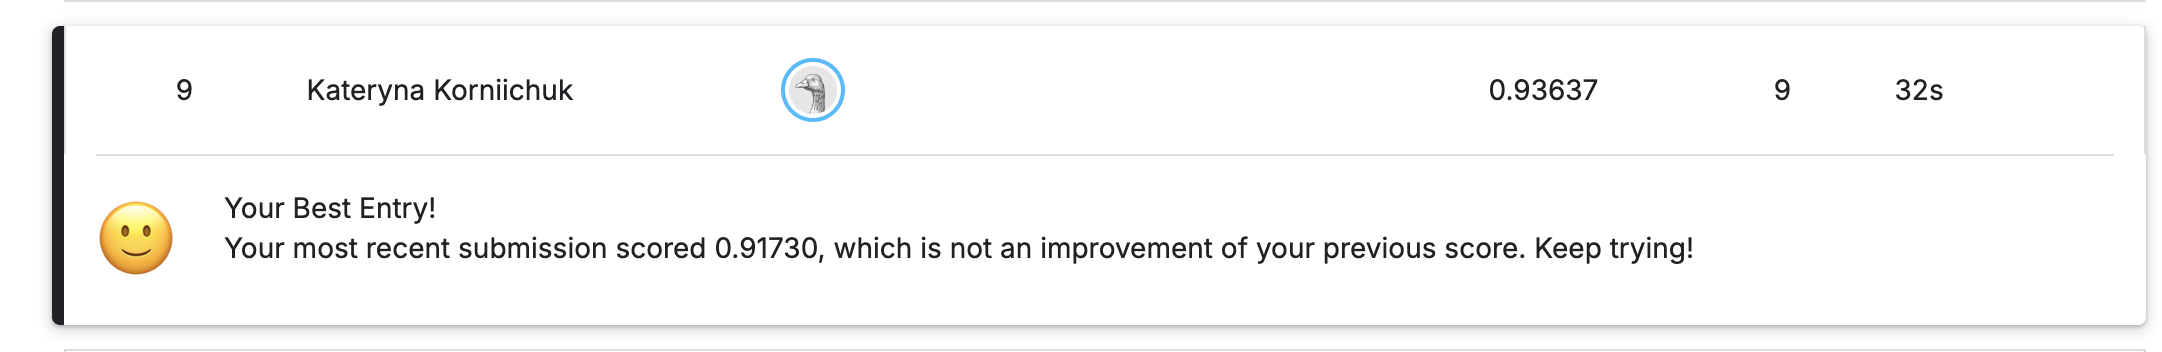

In [45]:
from IPython.display import Image, display

display(Image(filename='/content/Kaggle_score_2.png'))


**Висновки**

цікаво спробувати нові моделі і налаштування, але метрика AUROC в логістичній регресії була вище, чекаю ансамблів 🤞
